In [ ]:
#Load lybraries
import pandas as pd
import numpy as np
np.random.seed(0)
import matplotlib.pyplot as plt
import seaborn as sns
import math
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, silhouette_score, normalized_mutual_info_score, davies_bouldin_score, adjusted_rand_score
from sklearn.metrics import accuracy_score

from scipy.stats import norm, boxcox, weibull_max, pareto


from imblearn.over_sampling import SMOTE


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

from sklearn.decomposition import PCA, KernelPCA
from sklearn import tree
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn import svm
import scipy.spatial.distance as dist
from mpl_toolkits.mplot3d import Axes3D
  
import gc
import warnings
warnings.filterwarnings("ignore")
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier

In [ ]:
!pip install shap
import shap

     |████████████████████████████████| 564 kB 27.2 MB/s 


In [ ]:
#Load the data
df = pd.read_csv('/content/winequality-red.csv', sep=';')
#df = pd.read_csv('/content/winequality-white.csv', sep=';')

In [ ]:
df.shape

(1599, 12)

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.describe().to_latex()

'\\begin{tabular}{lrrrrrrrrrrrr}\n\\toprule\n{} &  fixed acidity &  volatile acidity &  citric acid &  residual sugar &    chlorides &  free sulfur dioxide &  total sulfur dioxide &      density &           pH &    sulphates &      alcohol &      quality \\\\\n\\midrule\ncount &    1599.000000 &       1599.000000 &  1599.000000 &     1599.000000 &  1599.000000 &          1599.000000 &           1599.000000 &  1599.000000 &  1599.000000 &  1599.000000 &  1599.000000 &  1599.000000 \\\\\nmean  &       8.319637 &          0.527821 &     0.270976 &        2.538806 &     0.087467 &            15.874922 &             46.467792 &     0.996747 &     3.311113 &     0.658149 &    10.422983 &     5.636023 \\\\\nstd   &       1.741096 &          0.179060 &     0.194801 &        1.409928 &     0.047065 &            10.460157 &             32.895324 &     0.001887 &     0.154386 &     0.169507 &     1.065668 &     0.807569 \\\\\nmin   &       4.600000 &          0.120000 &     0.000000 &        0.90

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df_Nan = df.copy()  #Create a aux. df

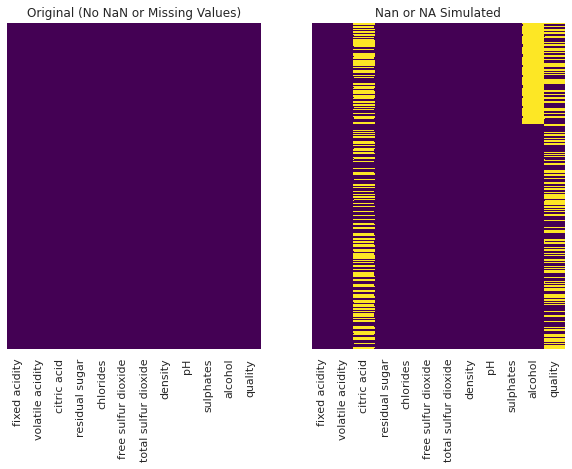

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10, 6), )
#To check if there exist N/A value
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0], )
axes[0].set_title('Original (No NaN or Missing Values)')

#To simulate NA value (into 3 features: 'alcohol', 'pH', 'quality'), if there exist N/A value
df_Nan['alcohol'][0:500] = np.NaN  #Input NaN value
df_Nan['quality'][np.random.randint(0, df.shape[0], 500)]  = np.NaN
df_Nan['citric acid'][np.random.randint(0, df.shape[0], 500)] = np.NaN
sns.heatmap(df_Nan.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[1] )
axes[1].set_title('Nan or NA Simulated')

plt.savefig('/content/drive/MyDrive/Overleaf/AMAE_pictures/Nan_searching.png')

Text(0.5, 0, 'Quality')

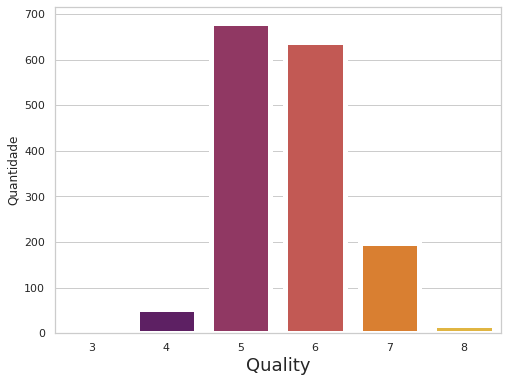

In [ ]:
#To check quality distribution
plt.figure(figsize=(8,6))

sns.countplot(x= "quality", data= df, linewidth= 5, palette="inferno" )
plt.ylabel("Quantidade")
plt.xlabel("Quality", fontsize=18)

In [ ]:
X = df.drop(columns='quality'); X
y = df.quality

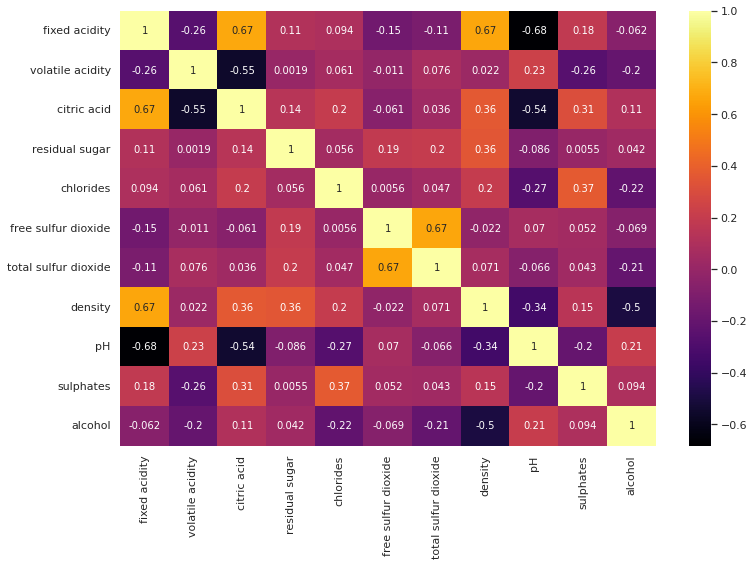

In [ ]:
#To check correlation among features
plt.figure(figsize=(12,8),)
sns.heatmap(X.corr(), annot=True, cmap='inferno' )

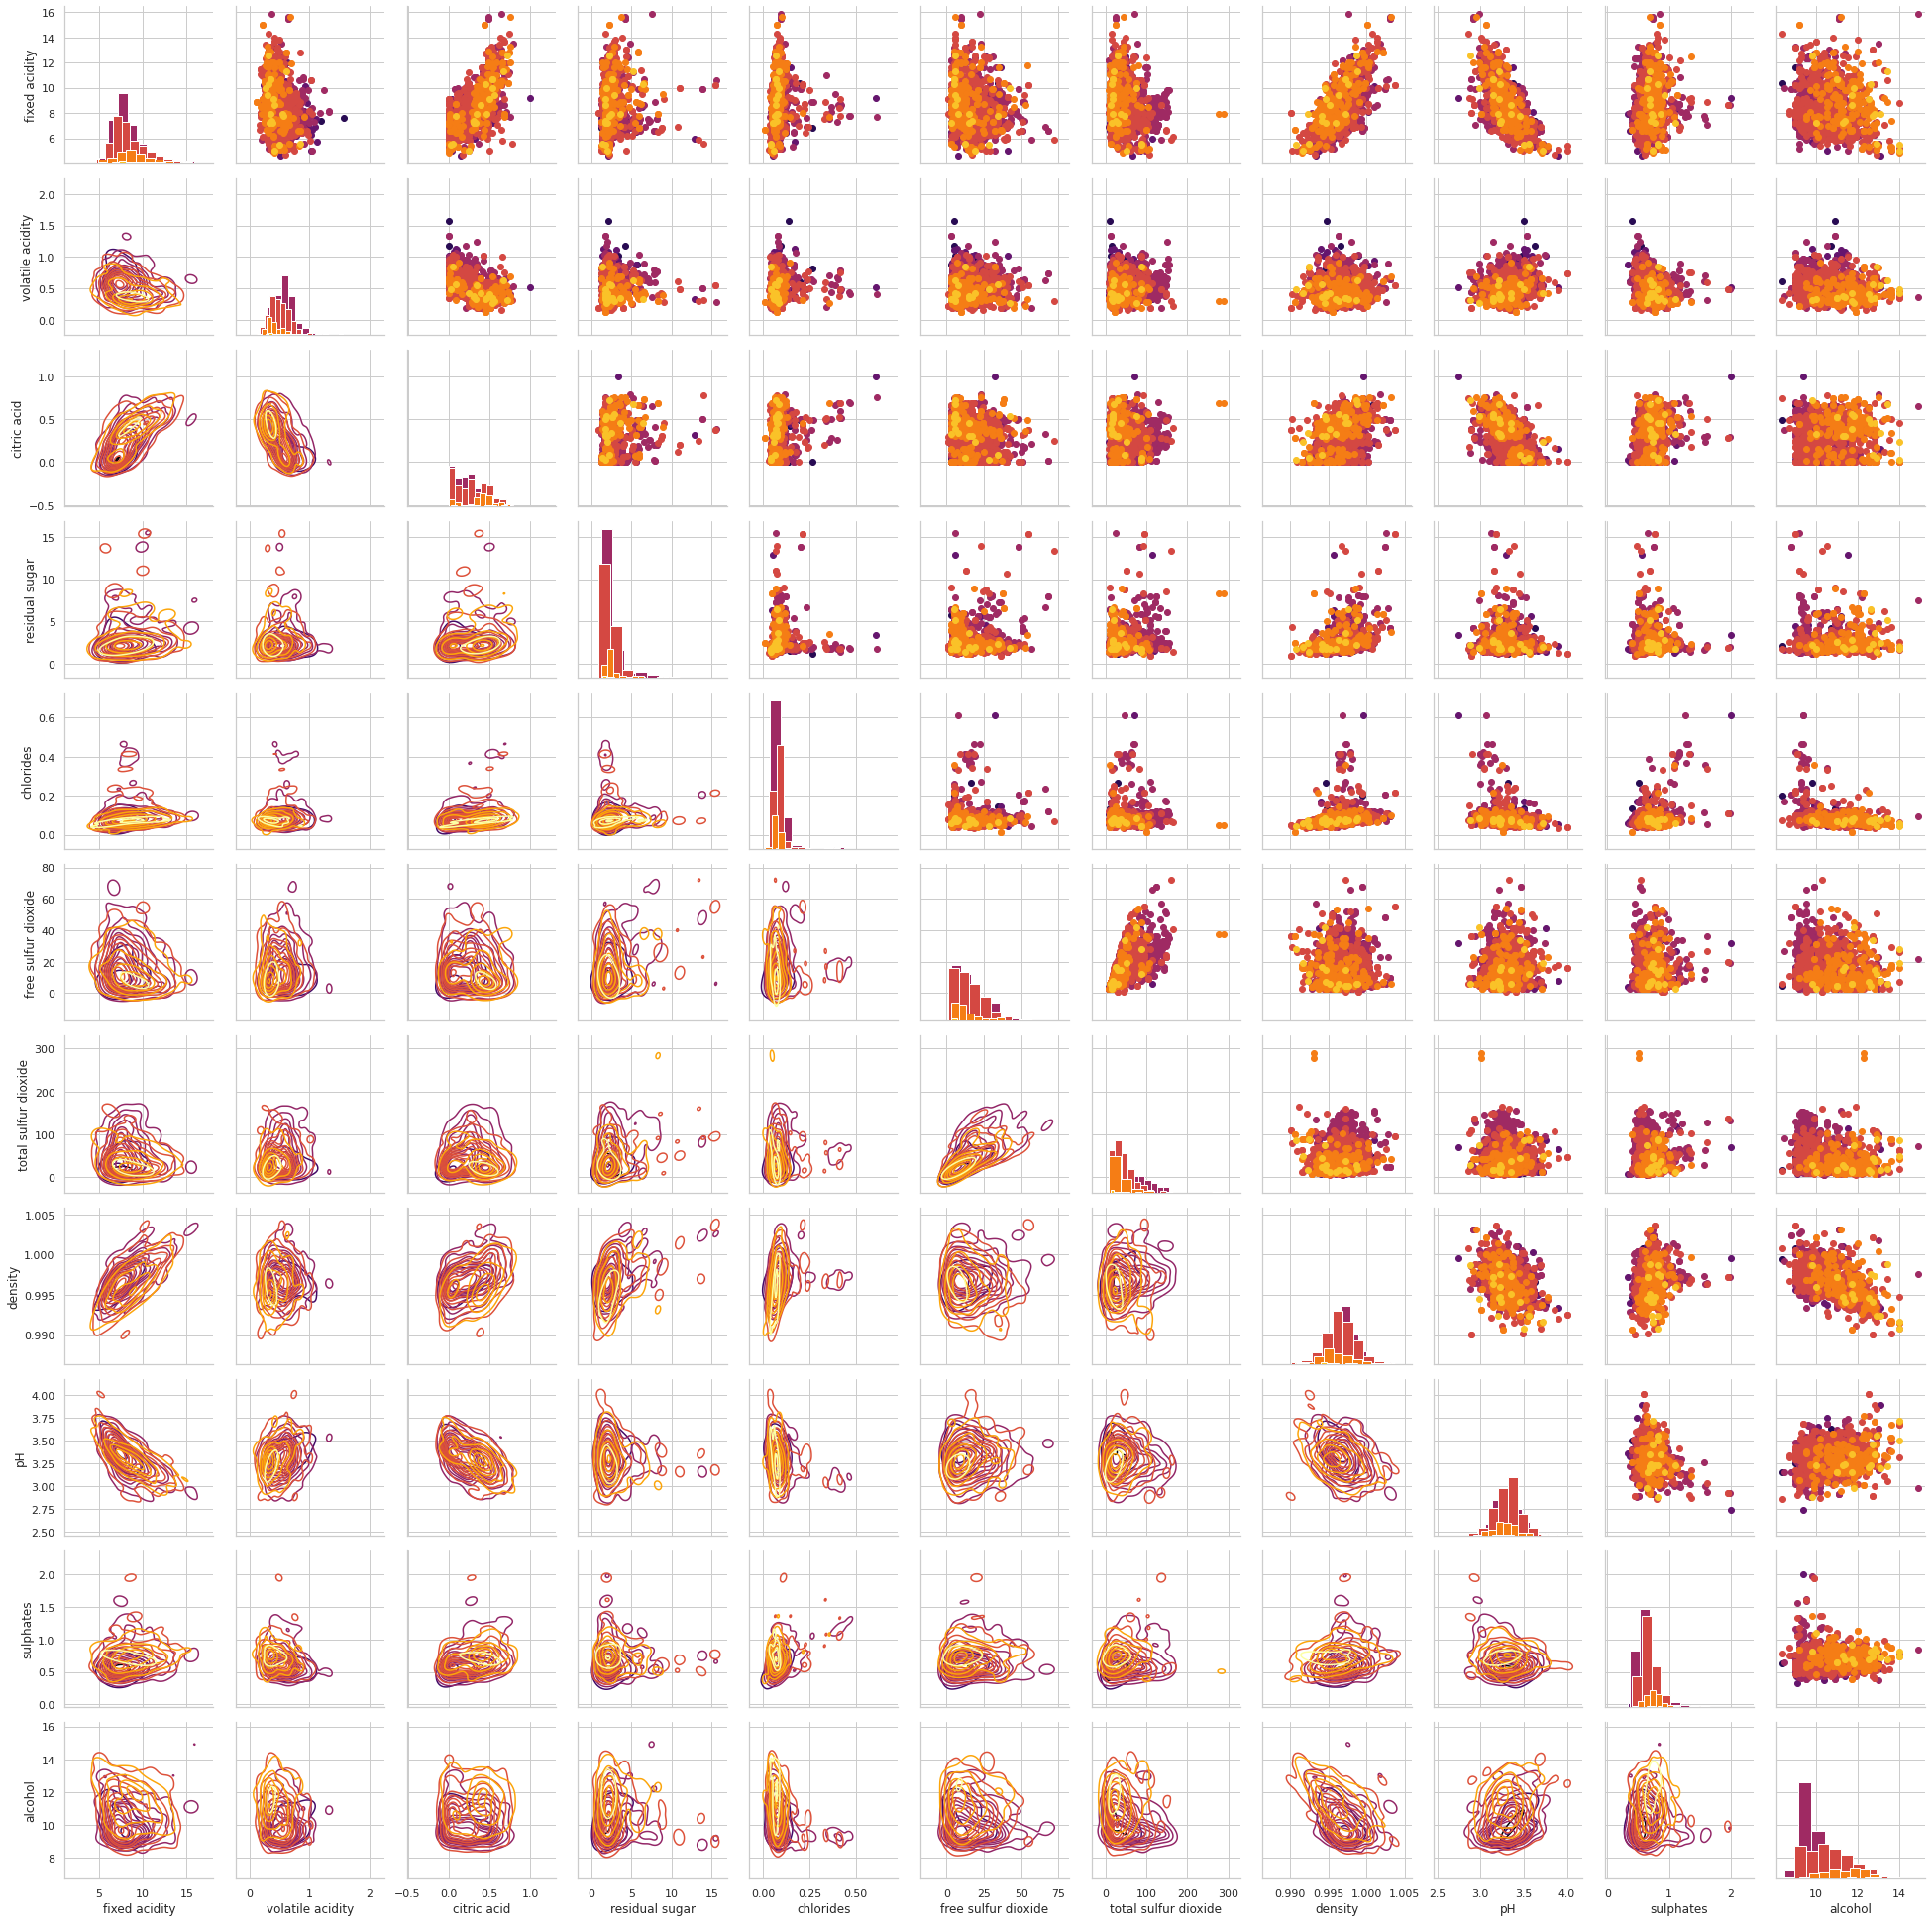

In [ ]:
# Altera os tipos de plots na diagonal, parte superior e inferior para analises geral dos dados por: histograma, scatterplot and kde
g = sns.PairGrid(df, palette='rainbow', hue='quality')
g.map_diag(plt.hist)
g.map_upper(plt.scatter, )
g.map_lower(sns.kdeplot)

In [ ]:
# fig, axes = plt.subplots(1,11, figsize=(40,6))

# for count, value in enumerate(df.columns[:-1]):
#     sns.boxplot(y=value, x='quality', data=df, palette='inferno', ax=axes[count] )
   
 

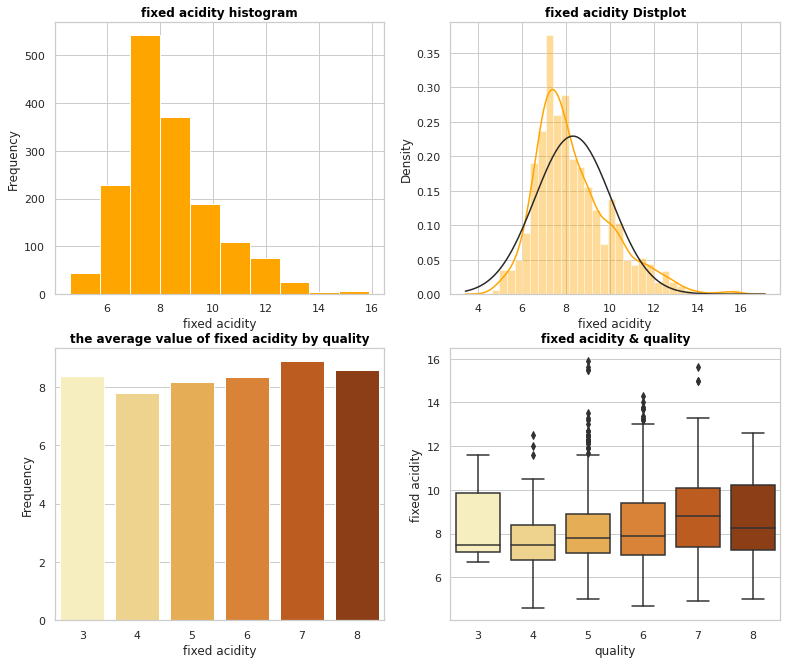

In [ ]:
#Análise exploratória de uma variável
quality = [3,4,5,6,7,8]
fixedAcidityMean = []

for each in quality:
    x = df[df["quality"] == each]
    mean = x["fixed acidity"].mean()
    fixedAcidityMean.append(mean)


plt.figure(figsize=(13, 11))
plt.subplot(2,2,1)
plt.hist(df["fixed acidity"], color="orange")
plt.xlabel("fixed acidity")
plt.ylabel("Frequency")
plt.title("fixed acidity histogram", color = "black", fontweight='bold', fontsize = 12)

plt.subplot(2,2,2)
sns.distplot(df["fixed acidity"], fit=norm, color="orange")
plt.title("fixed acidity Distplot", color = "black", fontweight='bold', fontsize = 12)

plt.subplot(2,2,3)
sns.barplot(x = quality, y = fixedAcidityMean, palette="YlOrBr")
plt.title("the average value of fixed acidity by quality", color = "black", fontweight='bold', fontsize = 12)
plt.xlabel("fixed acidity")
plt.ylabel("Frequency")

plt.subplot(2,2,4)
sns.boxplot(df['quality'], df["fixed acidity"], palette='YlOrBr')
plt.title("fixed acidity & quality", color = "black", fontweight= 'bold', fontsize = 12)

plt.show()

In [ ]:
#function to make EDA of data (Análise exploratória todas as variáveis)
def analise_exp_features(df, y):
 
  for i in  list(df.columns[:-1]):
    featureMean = []
    quality = y.unique()

    for each in quality:
        x = df[df["quality"] == each]
        mean = x[i].mean()
        featureMean.append(mean)


    plt.figure(figsize=(13, 11))
    plt.subplot(2,2,1)
    plt.hist(df[i], color="orange")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.title(i+" histogram", color = "black", fontweight='bold', fontsize = 12)

    plt.subplot(2,2,2)
    sns.distplot(df[i], fit=norm, color="orange")
    plt.title(i+" Distplot", color = "black", fontweight='bold', fontsize = 12)

    plt.subplot(2,2,3)
    sns.barplot(x = quality, y = featureMean, palette="YlOrBr")
    plt.title("the average value of "+i+" by quality", color = "black", fontweight='bold', fontsize = 12)
    plt.xlabel(i)
    plt.ylabel("Frequency")

    plt.subplot(2,2,4)
    sns.boxplot(df['quality'], df[i], palette='YlOrBr')
    plt.title(i+" & quality", color = "black", fontweight= 'bold', fontsize = 12)

    # plt.show()
    plt.savefig('/content/drive/MyDrive/Overleaf/AMAE_pictures/'+i+'.png')

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.wa

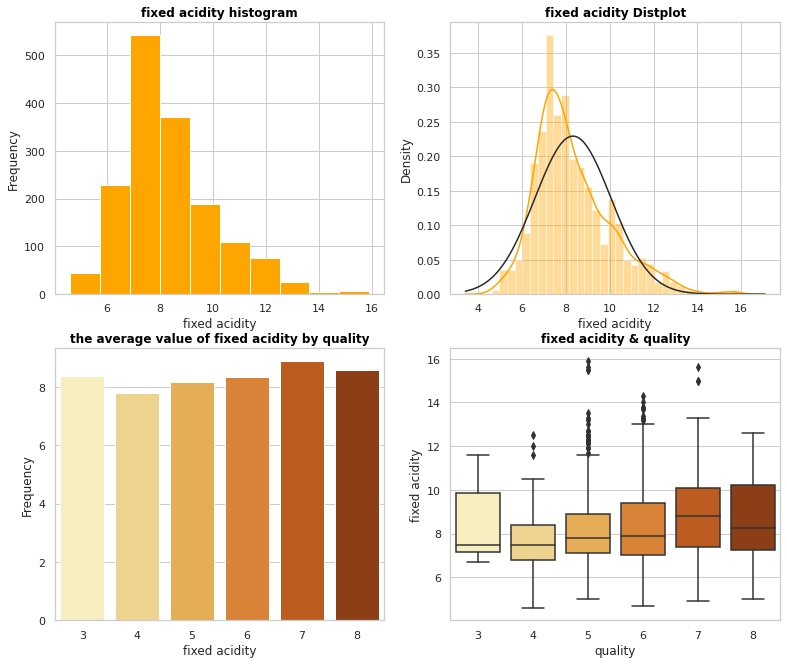

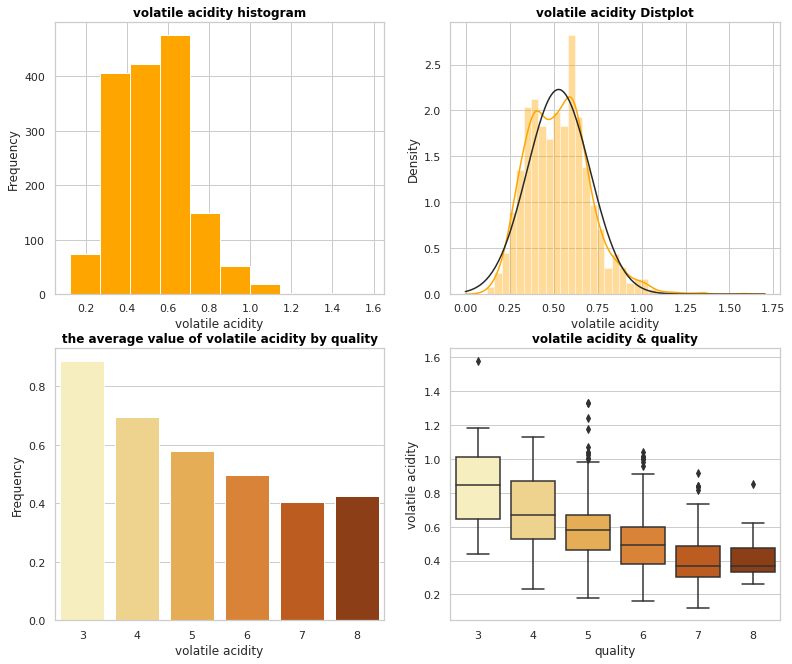

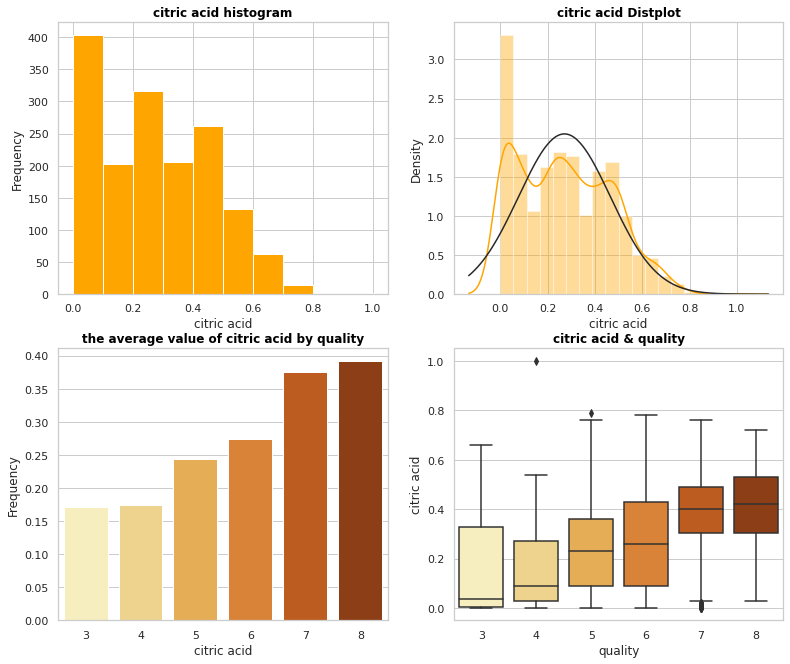

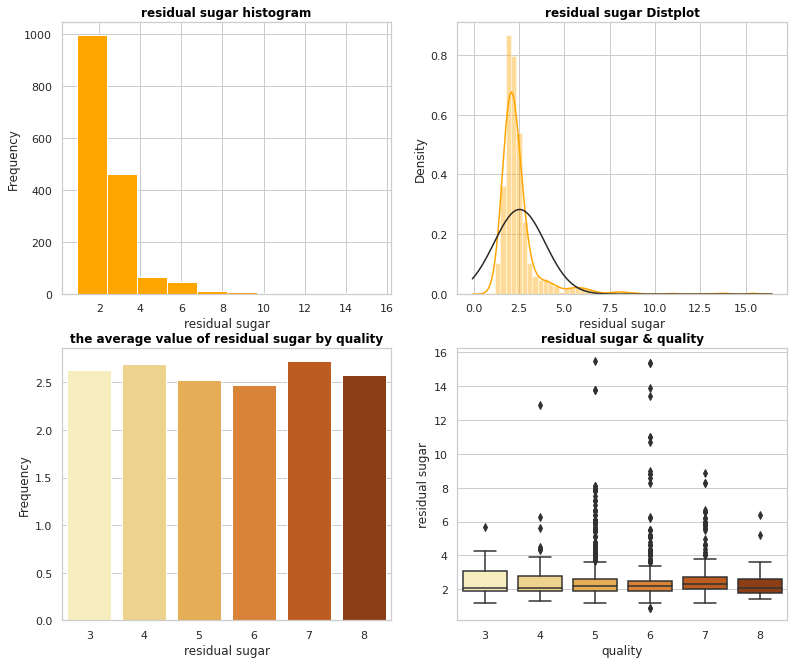

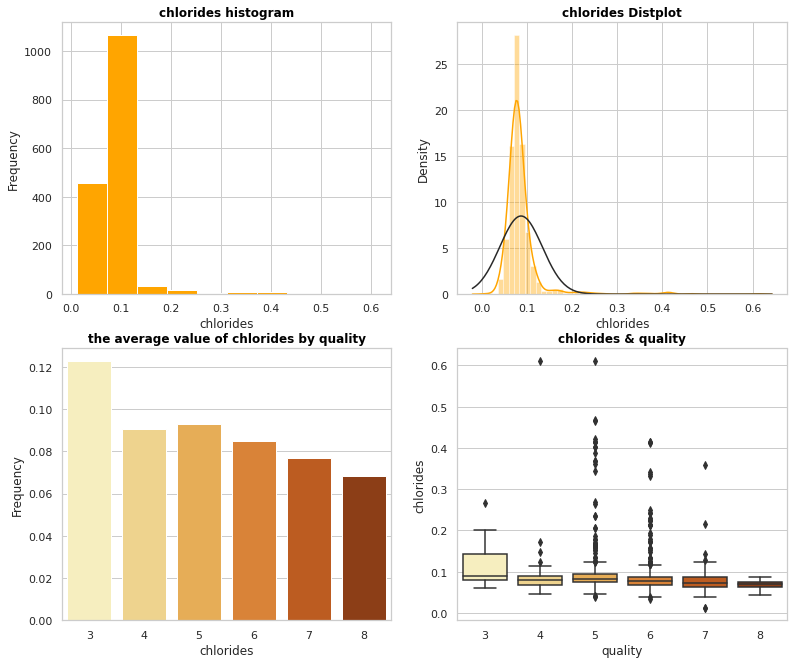

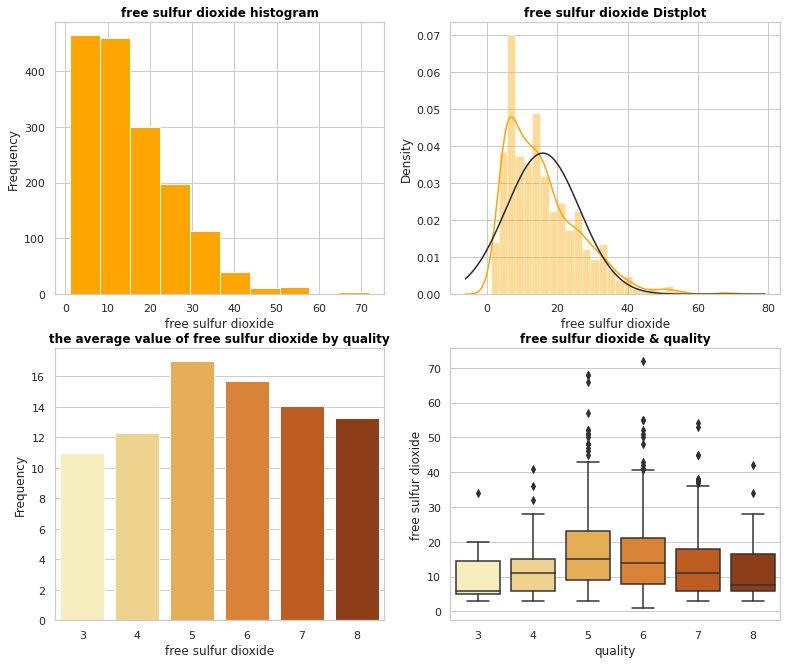

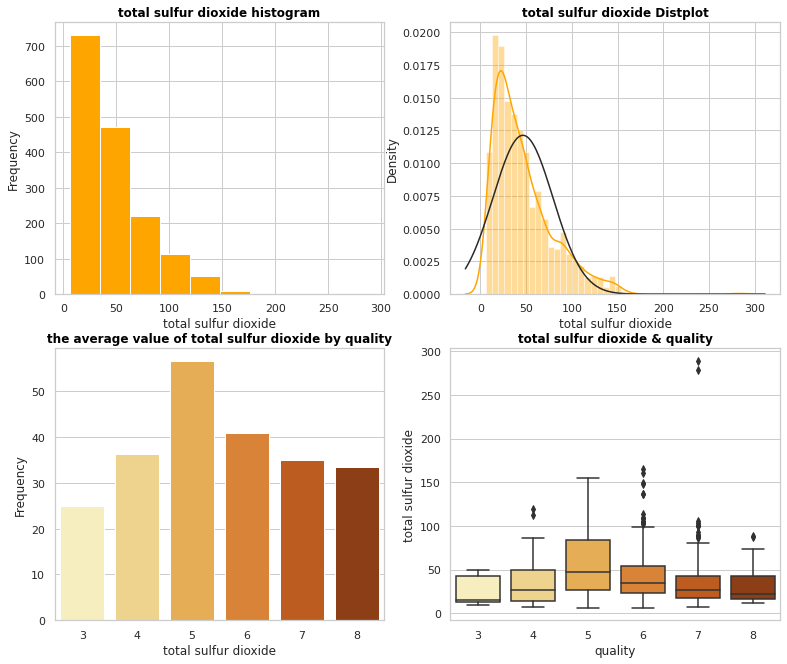

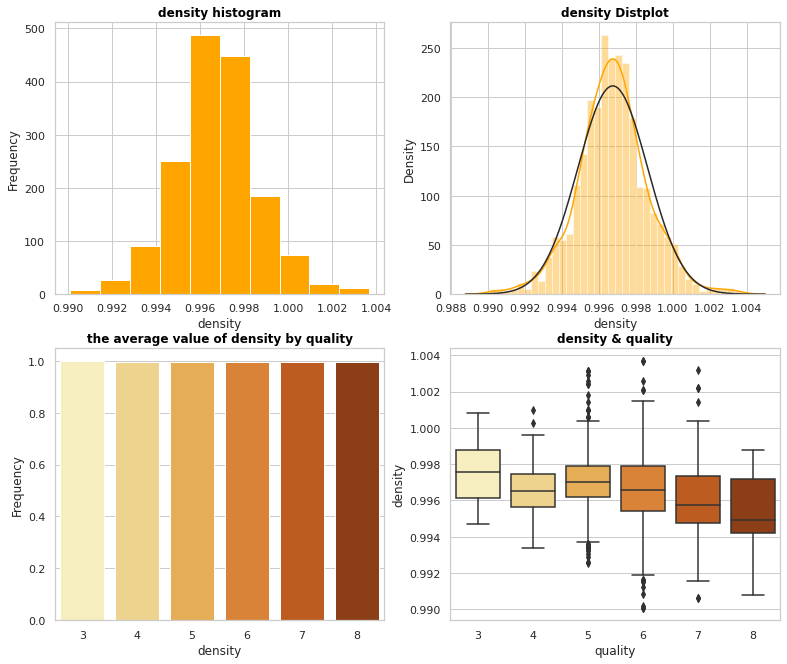

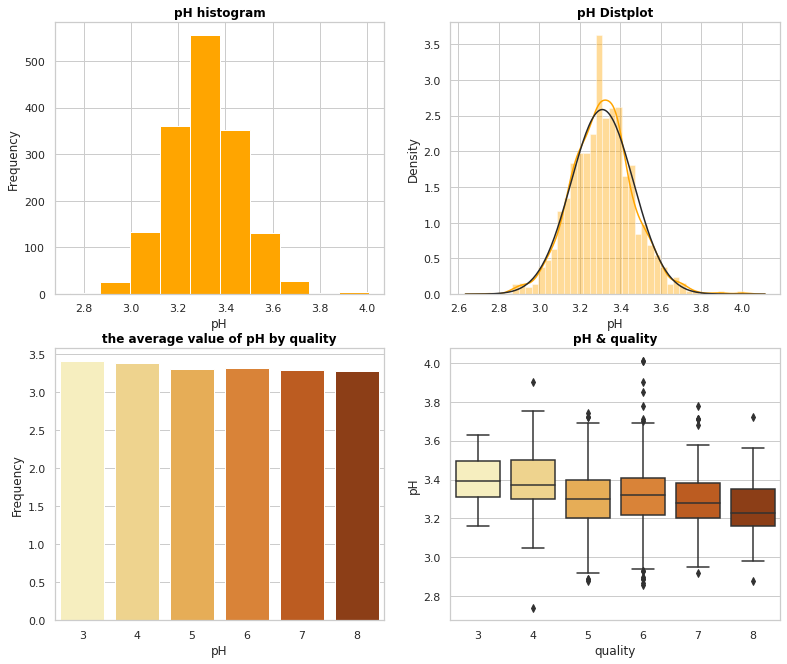

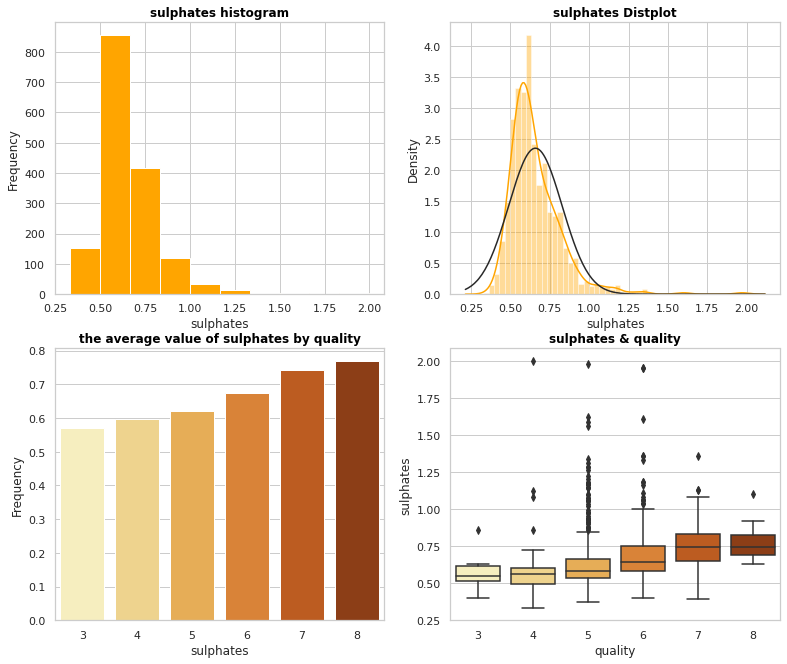

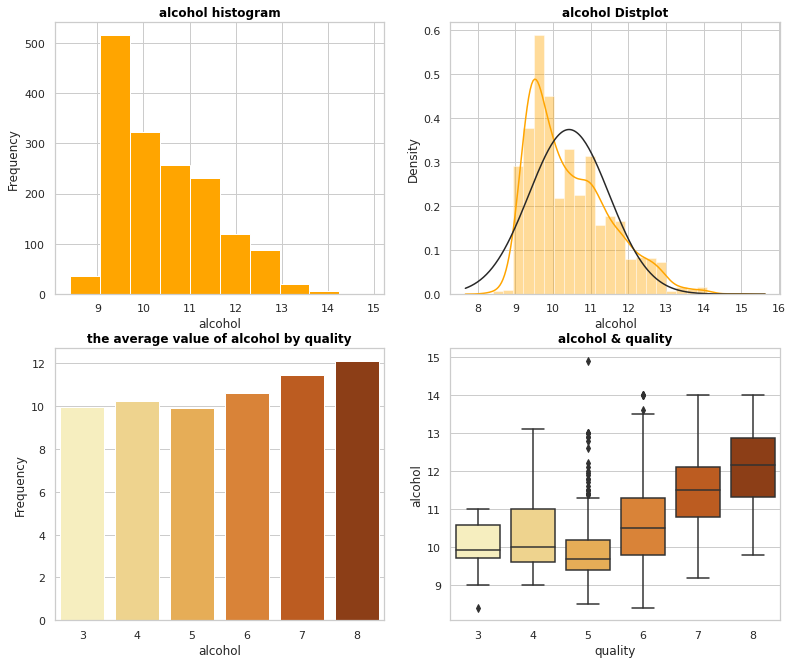

In [ ]:
analise_exp_features(df,y)

In [ ]:
#Analise visual dos dados em 2D

In [ ]:
X = df.drop(columns='quality')

In [ ]:
X_PCA = PCA(5)

In [ ]:
# X_PCA = X_PCA.fit_transform(np.log2(X+1))  #Transf. log2(X+1)
X_PCA = X_PCA.fit_transform(X)

In [ ]:
X_PCA[:, 0:2]

array([[-13.22490501,  -2.02389981],
       [ 22.03772361,   4.40832155],
       [  7.16267333,  -2.50146086],
       ...,
       [ -3.43135351,  14.27124349],
       [  1.13287834,  16.31616732],
       [ -3.8743766 ,   3.12634754]])

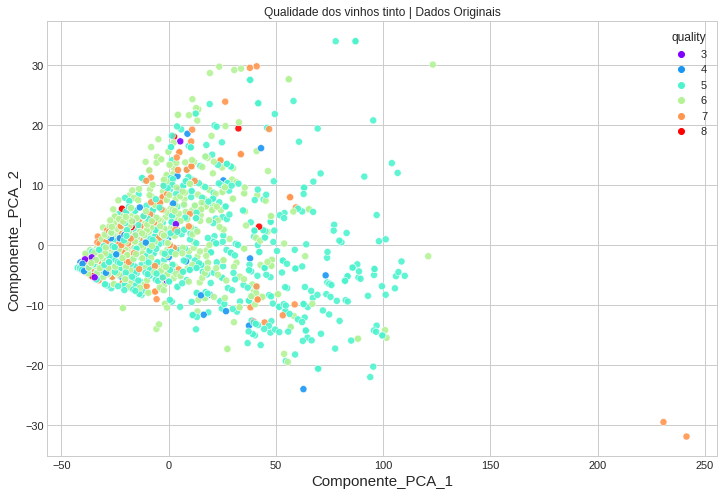

In [ ]:
plt.figure(figsize=(12,8))
plt.style.use("seaborn-whitegrid")
plt.xlabel('Componente_PCA_1', fontsize = 15)
plt.ylabel('Componente_PCA_2', fontsize = 15)
scat = sns.scatterplot(X_PCA[:,0], X_PCA[:,1], hue=df.quality, s=50, alpha= 0.9, palette="rainbow" )
scat.set_title("Qualidade dos vinhos tinto | Dados Originais")
#sns.scatterplot(X_tSNE[:,0], X_tSNE[:,1], hue= df_STAD[df_STAD.SUBTYPE != 'POLE'].dropna().SUBTYPE,  s=50, alpha= 0.9, ) 
#sns.scatterplot(X_tSNE[:,0], X_tSNE[:,1], s=50, alpha= 0.9, )   
plt.savefig('/content/drive/MyDrive/Overleaf/AMAE_pictures/Scatter_dadosoriginais_PCA.png')

In [ ]:
X_log = np.log2(X+1);X_log

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,3.070389,0.765535,0.000000,1.536053,0.105678,3.584963,5.129283,0.998412,2.173127,0.641546,3.378512
1,3.137504,0.910733,0.000000,1.847997,0.134878,4.700440,6.087463,0.997690,2.070389,0.748461,3.432959
2,3.137504,0.815575,0.056584,1.722466,0.126973,4.000000,5.781360,0.997834,2.090853,0.722466,3.432959
3,3.608809,0.356144,0.641546,1.536053,0.104337,4.169925,5.930737,0.998557,2.056584,0.659925,3.432959
4,3.070389,0.765535,0.000000,1.536053,0.105678,3.584963,5.129283,0.998412,2.173127,0.641546,3.378512
...,...,...,...,...,...,...,...,...,...,...,...
1594,2.847997,0.678072,0.111031,1.584963,0.124328,5.044394,5.491853,0.996316,2.153805,0.659925,3.523562
1595,2.786596,0.632268,0.137504,1.678072,0.086784,5.321928,5.700440,0.996476,2.176323,0.815575,3.608809
1596,2.867896,0.594549,0.176323,1.722466,0.105678,4.906891,5.357552,0.996924,2.144046,0.807355,3.584963
1597,2.786596,0.718088,0.163499,1.584963,0.104337,5.044394,5.491853,0.996729,2.192194,0.773996,3.485427


In [ ]:
# scaler = MinMaxScaler()
# scaler.fit(X_log)
# X_max_min = scaler.transform(X_log); X_max_min

#Coloca numa escla entre 0 e 1 apos log transformation ou padroniza para rodar kmeans
# X_MinMax = MinMaxScaler().fit_transform(X_log); X_MinMax
X_Stand =  StandardScaler().fit_transform(X); X_Stand


array([[-0.52835961,  0.96187667, -1.39147228, ...,  1.28864292,
        -0.57920652, -0.96024611],
       [-0.29854743,  1.96744245, -1.39147228, ..., -0.7199333 ,
         0.1289504 , -0.58477711],
       [-0.29854743,  1.29706527, -1.18607043, ..., -0.33117661,
        -0.04808883, -0.58477711],
       ...,
       [-1.1603431 , -0.09955388, -0.72391627, ...,  0.70550789,
         0.54204194,  0.54162988],
       [-1.39015528,  0.65462046, -0.77526673, ...,  1.6773996 ,
         0.30598963, -0.20930812],
       [-1.33270223, -1.21684919,  1.02199944, ...,  0.51112954,
         0.01092425,  0.54162988]])

In [ ]:
#Teste elbow method com kmeans
kmeans_kwargs = {"init": "random", "n_init": 10,"max_iter": 300, "random_state": 42}

# A list holds the SSE values for each k
sse = []
for k in range(1, math.ceil(math.sqrt(df.shape[0]))):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X_Stand)
    sse.append(kmeans.inertia_)

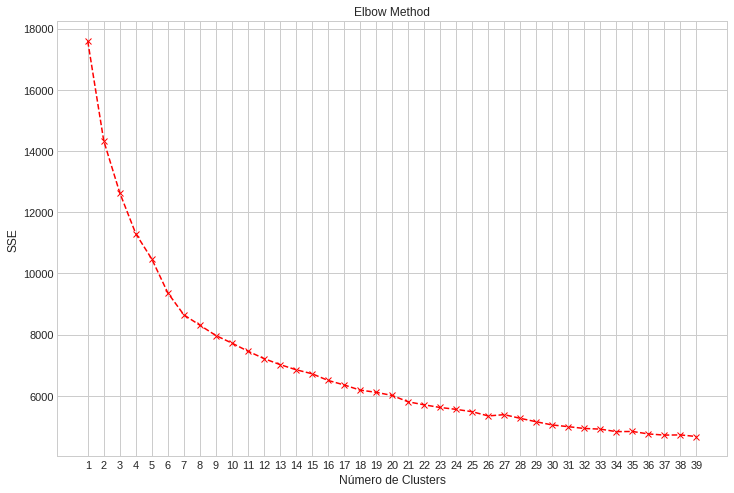

In [ ]:
#Plot Elbow Method
plt.figure(figsize=(12,8))
plt.style.use("seaborn-whitegrid")
plt.plot(range(1, math.ceil(math.sqrt(df.shape[0]))), sse,  color='red', marker='x', linestyle='dashed')
# plt.vlines(kl.elbow, ymin=np.min(sse)-0.1, ymax=np.max(sse), linestyles='dashed', colors= 'r' )
plt.xticks(range(1, math.ceil(math.sqrt(df.shape[0]))))
plt.xlabel("Número de Clusters")
plt.ylabel("SSE")
plt.title('Elbow Method')
plt.savefig('/content/drive/MyDrive/Overleaf/AMAE_pictures/Elbow_method.png')
plt.show()


In [ ]:
#Teste com k-means
kmeans = KMeans(init="random", n_clusters=2, n_init=10,  max_iter=300, random_state=42)
#kmeans = KMeans(init="random", n_clusters=4, n_init=10,  max_iter=300, random_state=42)
kmeans.fit(X_Stand)

KMeans(init='random', n_clusters=2, random_state=42)

In [ ]:
#Aplica ARI para veriricar accuracy
adjusted_rand_score(y, kmeans.labels_)

0.043716089558632175

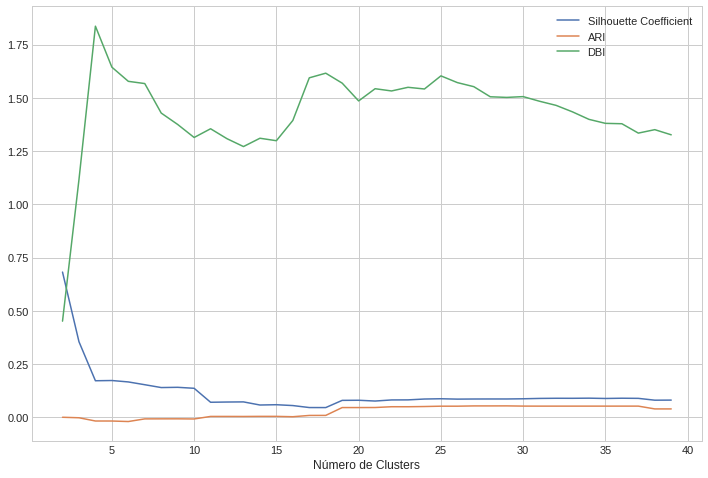

In [ ]:
#Comparando datasets silhouette e ARI (K-means and HC)
plt.style.use("seaborn-whitegrid")
kmeans_kwargs = {"init": "random", "n_init": 10,"max_iter": 500, "random_state": 42}
HC_kwargs = {"linkage": "complete"}
# A list holds the SSE values for each k
# fig, axes = plt.subplots(1, 2, figsize = (20,8), constrained_layout=True)
plt.figure(figsize=(12, 8))
# axes = axes.flatten()
#fig.style.use("seaborn")
count = 0

# A list holds the silhouette coefficients for each k
silhouette_coefficients = [];  ari_scores = []; DBI = []
#silhouette_coefficients_HC = []; ari_scores_HC = []
#silhouette_coefficients_gmm = []; ari_scores_gmm = []
  
# Notice you start at 2 clusters for silhouette coefficient
for k in range(2,math.ceil(math.sqrt(X.shape[0]))):
  #kmeans = MiniBatchKMeans(n_clusters=2,
                          #random_state=0,
                          #batch_size=6,
                          #max_iter=10)
  # cluster = KMeans(n_clusters=k, **kmeans_kwargs)
  # cluster.fit(X_Stand)  

  cluster = AgglomerativeClustering(n_clusters=k, affinity= "euclidean", **HC_kwargs)
  cluster.fit(X_Stand)  
  score_S = silhouette_score(X_Stand, cluster.labels_)
  score_ARI = adjusted_rand_score(y, cluster.labels_)  
  DBI_score = davies_bouldin_score(X_Stand, cluster.labels_)
  silhouette_coefficients.append(score_S)
  ari_scores.append(score_ARI)
  DBI.append(DBI_score)


plt.plot(range(2, math.ceil(math.sqrt(X.shape[0]))), silhouette_coefficients, label='Silhouette Coefficient')
plt.plot(range(2, math.ceil(math.sqrt(X.shape[0]))), ari_scores, label = 'ARI')
plt.plot(range(2, math.ceil(math.sqrt(X.shape[0]))), DBI, label='DBI')

plt.xlabel("Número de Clusters")
plt.legend()
plt.savefig('/content/drive/MyDrive/Overleaf/AMAE_pictures/Qualidade_cluster.png')
plt.show()

In [ ]:
y.unique()

[0, 1]
Categories (2, int64): [0 < 1]

In [ ]:
#Teste com DBSCAN
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=7)
nbrs = neigh.fit(X_Stand)
distances, indices = nbrs.kneighbors(X_Stand)
#nbrs = neigh.fit(Z)
#distances, indices = nbrs.kneighbors(Z)

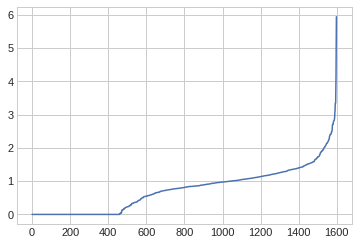

In [ ]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances,)

In [ ]:
dbscan = DBSCAN(eps=1.8, min_samples=7, metric="euclidean" )
dbscan.fit(X_Stand)

DBSCAN(eps=1.8, min_samples=7)

In [ ]:
#Aplica ARI para veriricar accuracy
adjusted_rand_score(y, dbscan.labels_)

0.019088849016370403

In [ ]:
# np.array(dbscan.labels_).tolist()

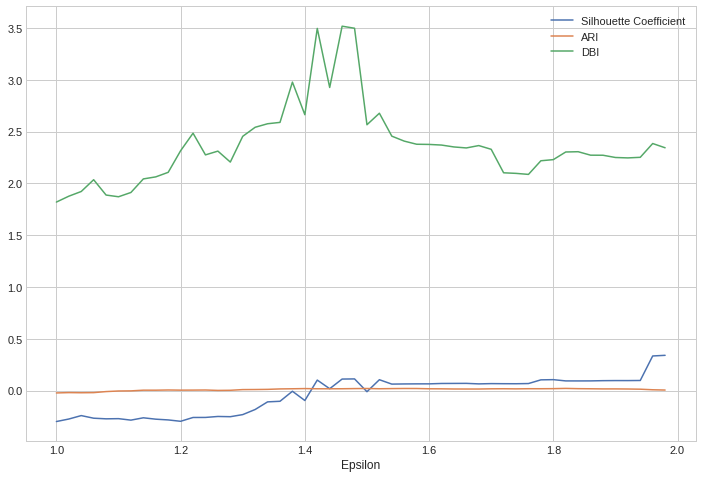

In [ ]:
#Comparando datasets silhouette e ARI DBSCAN
plt.style.use("seaborn-whitegrid")
# kmeans_kwargs = {"init": "random", "n_init": 10,"max_iter": 500, "random_state": 42}
HC_kwargs = {"linkage": "complete"}
# A list holds the SSE values for each k
# fig, axes = plt.subplots(1, 2, figsize = (20,8), constrained_layout=True)
plt.figure(figsize=(12, 8))
# axes = axes.flatten()
#fig.style.use("seaborn")
count = 0

# A list holds the silhouette coefficients for each k
silhouette_coefficients = [];  ari_scores = []; DBI = []
#silhouette_coefficients_HC = []; ari_scores_HC = []
#silhouette_coefficients_gmm = []; ari_scores_gmm = []
  
# Notice you start at 2 clusters for silhouette coefficient
for k in np.arange(1, 2., 0.02):
 
  cluster = DBSCAN(eps=k, min_samples=7, metric="euclidean")
  cluster.fit(X_Stand)

  score_S = silhouette_score(X_Stand, cluster.labels_)
  score_ARI = adjusted_rand_score(y, cluster.labels_)
  DBI_score = davies_bouldin_score(X_Stand, cluster.labels_)

  silhouette_coefficients.append(score_S)
  ari_scores.append(score_ARI)
  DBI.append(DBI_score)


plt.plot(np.arange(1, 2., 0.02), silhouette_coefficients, label='Silhouette Coefficient')
plt.plot(np.arange(1, 2., 0.02), ari_scores, label = 'ARI')
plt.plot(np.arange(1, 2., 0.02), DBI, label='DBI')

plt.xlabel("Epsilon")
plt.legend()
plt.savefig('/content/drive/MyDrive/Overleaf/AMAE_pictures/DBSCAN_Qualidade_cluster.png')
plt.show()

In [ ]:
dbscan = DBSCAN(eps=1.85, min_samples=7, metric="euclidean" )
dbscan.fit(X_Stand)

DBSCAN(eps=1.85, min_samples=7)

In [ ]:
unique, counts = np.unique(np.array(dbscan.labels_), return_counts=True)
result = np.column_stack((unique, counts)) 
print (result)

[[  -1  192]
 [   0 1377]
 [   1   11]
 [   2    9]
 [   3   10]]


In [ ]:
y

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

# Classificação e Feature Selection

In [ ]:
#Load the data
df = pd.read_csv('/content/winequality-red.csv', sep=';')
#df = pd.read_csv('/content/winequality-white.csv', sep=';')

In [ ]:
bins = (2, 6.5, 8)
labels = [0, 1]
df['quality'] = pd.cut(x = df['quality'], bins = bins, labels = labels)

In [ ]:
y = df.quality
X = df.drop(["quality"], axis = 1)

In [ ]:
df['quality'].value_counts()

0    1382
1     217
Name: quality, dtype: int64

In [ ]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [ ]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: category
Categories (2, int64): [0 < 1]

In [ ]:
#Test several classifiers
X_Train, X_Test, y_Train, y_Test = train_test_split(np.log2(X+1), y, test_size = 0.20, random_state = 42)
# X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

In [ ]:
#Synthetic data generation in train set
sm = SMOTE(random_state=14)
X_Train_sm, y_Train_sm = sm.fit_resample(X_Train, y_Train)  #Create artificial samples just in train set

In [ ]:
X_Train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,3.277985,0.757023,0.389567,2.000000,0.119024,4.584963,6.357552,1.000144,2.163499,0.799087,3.655352
354,2.827819,0.275007,0.485427,1.263034,0.092207,5.375039,7.375039,0.993638,2.087463,0.669027,3.689299
342,3.572890,0.475085,0.555816,1.485427,0.160920,2.807355,3.906891,0.998701,2.104337,0.807355,3.432959
834,3.292782,0.752749,0.333424,1.378512,0.121679,4.087463,4.584963,0.997791,2.111031,0.555816,3.378512
705,3.232661,1.025029,0.201634,2.807355,0.101650,3.584963,5.781360,0.999278,2.127633,0.575312,3.446256
...,...,...,...,...,...,...,...,...,...,...,...
1130,3.336283,0.678072,0.000000,1.536053,0.081340,2.584963,3.459432,0.998340,2.063503,0.704872,3.510962
1294,3.201634,0.709291,0.137504,1.632268,0.101650,4.700440,5.930737,0.997386,2.100978,0.807355,3.572890
860,3.035624,0.695994,0.084064,1.887525,0.107018,4.000000,6.426265,0.998167,2.173127,0.622930,3.392317
1459,3.153805,0.263034,0.432959,1.432959,0.075875,3.000000,4.000000,0.996085,2.111031,0.847997,3.689299


In [ ]:
#Staralize all data
scaler = StandardScaler()  
# scaler = MinMaxScaler()
X_Train_sm = scaler.fit_transform(X_Train_sm)
X_Test = scaler.transform(X_Test) 

In [ ]:
X_Train_sm.max()

11.805434434186965

In [ ]:
import collections
print("Before smote --> ", collections.Counter(y_Train))
print("After smote --> ", collections.Counter(y_Train_sm))

Before smote -->  Counter({0: 1109, 1: 170})
After smote -->  Counter({0: 1109, 1: 1109})


In [ ]:
#Classifiers selection

# names = ["Nearest Neighbors", "Linear SVM", "RBF SVM", "Gaussian Process",
#          "Decision Tree", "Random Forest", "Neural Net", "AdaBoost",
#          "Naive Bayes", "QDA", "LR", "LRCV", 'XGBoost']

names = ["Nearest Neighbors", 
         "Decision Tree", 
         "Random Forest", 
         "LR",
         "LRCV"
         ]

# classifiers = [KNeighborsClassifier(3),
#     SVC(kernel="linear", C=0.05),
#     SVC(gamma=2, C=1),
#     GaussianProcessClassifier(1.0 * RBF(1.0)),
#     DecisionTreeClassifier(max_depth=5),
#     RandomForestClassifier(n_estimators=500),
#     MLPClassifier(alpha=1, max_iter=1000),
#     AdaBoostClassifier(),
#     GaussianNB(),
#     QuadraticDiscriminantAnalysis(), 
#     LogisticRegression(random_state = 42, ), 
#     LogisticRegressionCV(cv=10,  random_state = 42, class_weight='balanced', ), 
#     xgb.XGBClassifier()
#     ]

classifiers = [
              KNeighborsClassifier(3),
              DecisionTreeClassifier(max_depth=5),
              RandomForestClassifier(n_estimators=500),
              LogisticRegression(random_state = 42, ), 
              LogisticRegressionCV(cv=10,  random_state = 42, )
              ]

In [ ]:
# iterate over classifiers
for name, clf in zip(names, classifiers):
      #ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
      clf.fit(X_Train_sm, y_Train_sm)
      score = clf.score(X_Test, y_Test)
      print(name + str('====>') + str(score))

Nearest Neighbors====>0.8
Decision Tree====>0.796875
Random Forest====>0.925
LR====>0.815625
LRCV====>0.8125


In [ ]:
#To verify accuracy
import time
start = time.process_time()
trainedforest = RandomForestClassifier(n_estimators=500).fit(X_Train_sm,y_Train_sm)

# #trainedforest = DecisionTreeClassifier(criterion='entropy', max_depth=5).fit(X_Train,y_Train)
# trainedforest = xgb.XGBClassifier(max_depth=5, n_estimators=200, ).fit(X_Train,y_Train)
print('O tempo de execução foi: {:2f} seg'.format(time.process_time() - start))
predictionforest = trainedforest.predict(X_Test)
print(confusion_matrix(y_Test,predictionforest))
print(classification_report(y_Test,predictionforest))

O tempo de execução foi: 2.609946 seg
[[256  17]
 [  9  38]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       273
           1       0.69      0.81      0.75        47

    accuracy                           0.92       320
   macro avg       0.83      0.87      0.85       320
weighted avg       0.93      0.92      0.92       320



(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 <a list of 11 Text major ticklabel objects>)

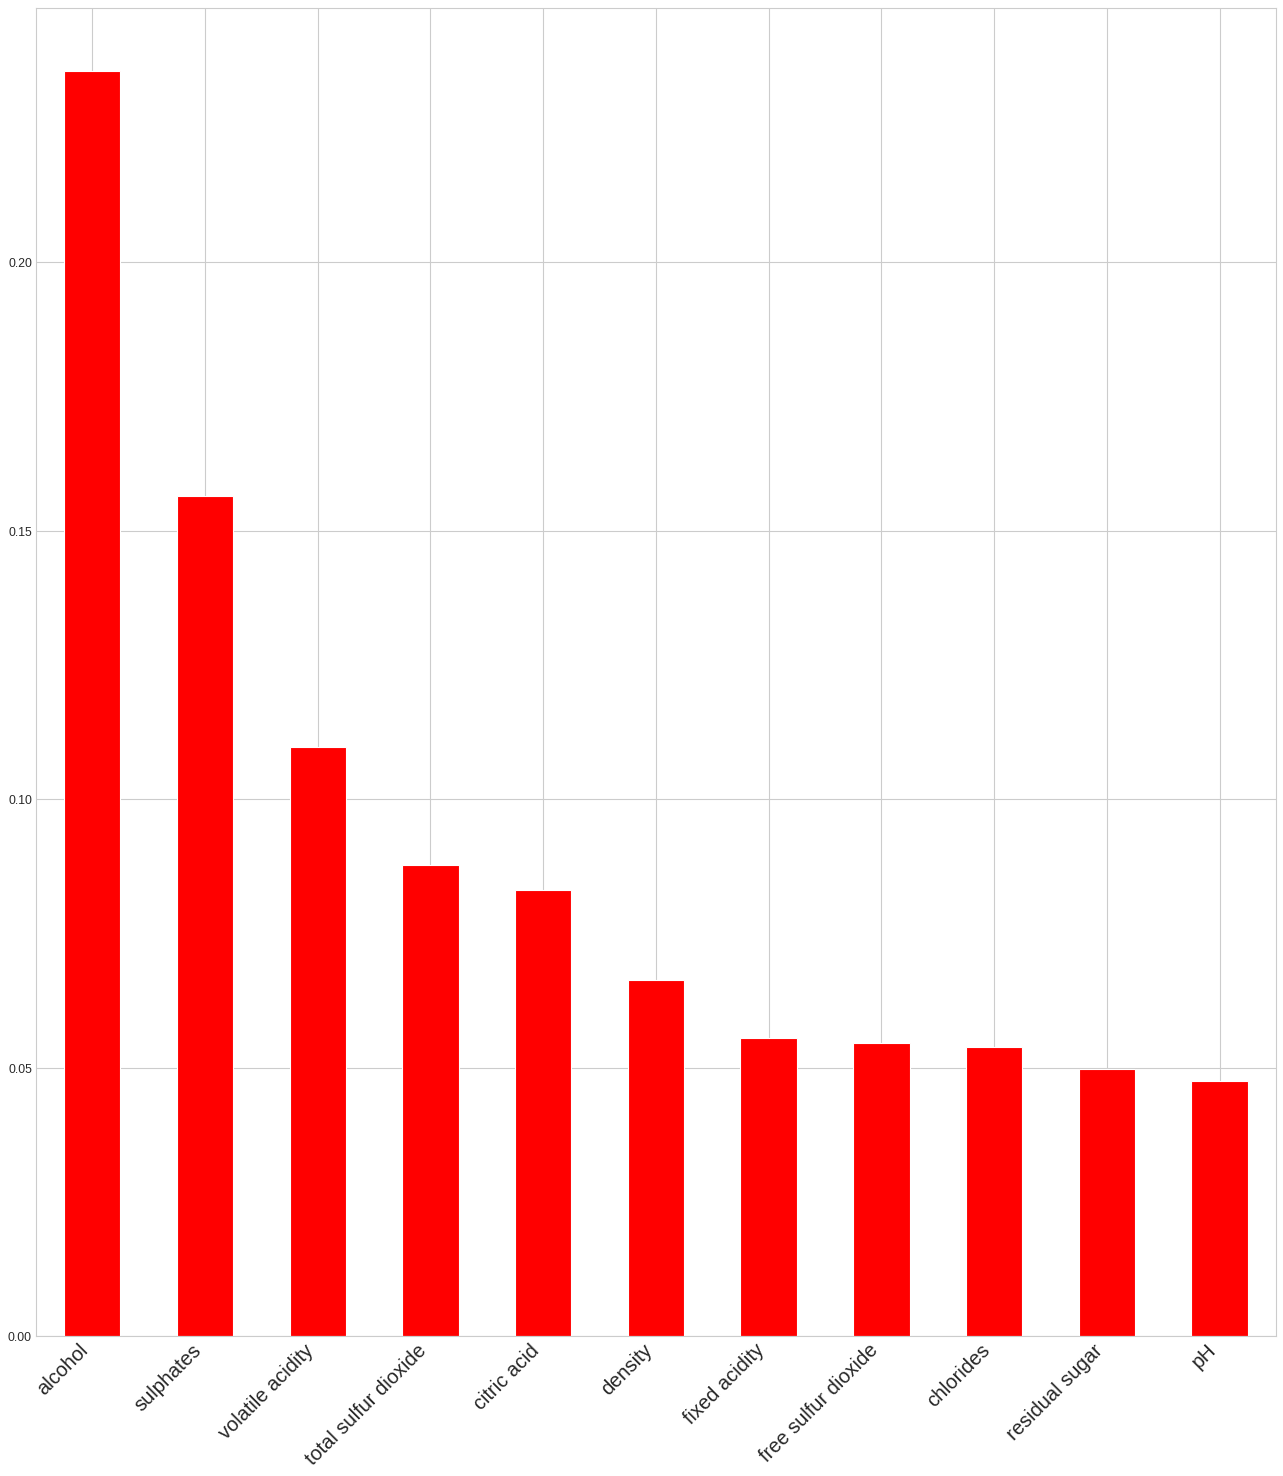

In [ ]:
#Plot feature importance RF

plt.figure(num=None,  figsize=(20, 22), dpi=80, facecolor='w', edgecolor='k')
plt.labelsize = 18
plt.titlesize = 16
# plt.xlabel('Variaveis', fontsize = 18)

feat_importances = pd.Series(trainedforest.feature_importances_, index= X.columns)
feat_importances.nlargest(11).plot(kind='bar', color='red')
plt.xticks(rotation=45, ha='right', fontsize=18)

In [ ]:
# samples = pd.DataFrame (X_Train_sm, columns = X_Train.columns,)
samples = pd.DataFrame (X_Test, columns = X_Train.columns)

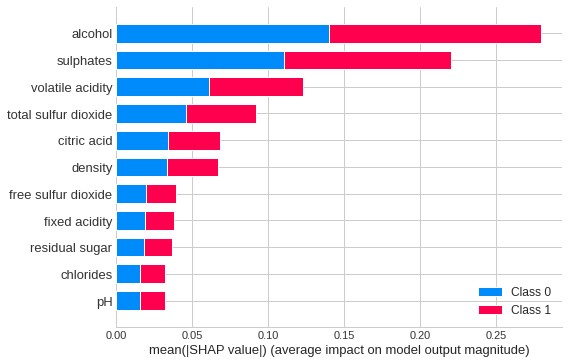

In [ ]:
explainer = shap.TreeExplainer(trainedforest)
shap_values = explainer.shap_values(samples, )
#shap.plots.beeswarm(shap_values, max_display=15)
shap.summary_plot(shap_values, samples, max_display=11, )

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 11.4 µs


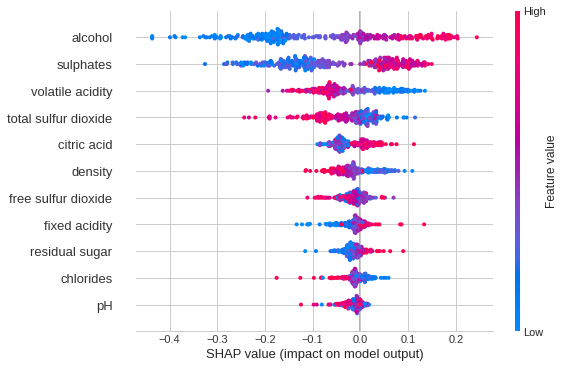

In [ ]:
shap.initjs()

# Let us have a look on SHAP summary plot
%time
# samples = pd.DataFrame (X_Test, columns = X_Train.columns,)

# explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(samples, approximate=False, check_additivity=False)

shap.summary_plot(shap_values[1], samples)

In [ ]:
###################FIM